# SenseNova: AI Chat and Image Generation by SenseTime

Welcome to this tutorial on **SenseNova** by **SenseTime**! SenseNova is a family of large-scale multimodal AI models developed by SenseTime, one of China leading AI companies. The SenseNova platform provides an OpenAI-compatible API, making it easy to integrate into existing workflows.

In this notebook, we will explore two powerful SenseNova models:

* **SenseNova 6.7 Flash-Lite**: A fast and efficient chat model that supports text conversations and includes a unique **reasoning** field showing the model chain-of-thought.
* **SenseNova U1 Fast**: A high-quality image generation model that creates images from text prompts.

**Key Concepts Covered:**

* **OpenAI SDK Compatibility**: Using the OpenAI Python SDK with SenseNova API.
* **Chat Completions**: Basic and multi-turn text conversations.
* **Reasoning Field**: Exploring the model internal thinking process.
* **Image Generation**: Creating images from text prompts and displaying them.

## 1. Setup

First, let us install the necessary Python libraries and configure our API credentials.

### 1.1 Install Libraries

We will use the openai Python SDK (which is compatible with SenseNova API) and requests for any additional HTTP calls.

In [1]:
# Uncomment the following line to install the required packages
# %pip install openai requests

### 1.2 Configure API Key and Initialize Client

SenseNova API is fully OpenAI-compatible. Simply point the base_url to https://token.sensenova.cn/v1 and provide your API key. You can get an API key from the SenseNova platform.

For security, we recommend storing your API key in an environment variable or a .env file. For this demo, we will use the environment variable SENSENOVA_API_KEY with a fallback.

In [2]:
import os
from openai import OpenAI

# Set your API key here, or set the SENSENOVA_API_KEY environment variable
SENSENOVA_API_KEY = os.environ.get("SENSENOVA_API_KEY", "sk-Qu7Du51h9VDUTt3wDnZvsoJkl9qehr7k")
SENSENOVA_BASE_URL = "https://token.sensenova.cn/v1"

# Initialize the OpenAI client with SenseNova base URL
client = OpenAI(
    api_key=SENSENOVA_API_KEY,
    base_url=SENSENOVA_BASE_URL,
)

print("SenseNova client initialized successfully!")
print(f"Base URL: {SENSENOVA_BASE_URL}")

SenseNova client initialized successfully!
Base URL: https://token.sensenova.cn/v1


## 2. Chat Completions with SenseNova 6.7 Flash-Lite

SenseNova 6.7 Flash-Lite is a fast and efficient chat model. It uses the standard OpenAI chat completions format, so you can use the same SDK calls you are already familiar with.

One notable feature is the **reasoning** field in the response, which reveals the model internal chain-of-thought thinking process.

### 2.1 Basic Text Chat

Let us start with a simple single-turn chat completion.

In [3]:
# Basic text chat completion
response = client.chat.completions.create(
    model="sensenova-6.7-flash-lite",
    messages=[
        {"role": "user", "content": "What is SenseNova by SenseTime? Answer in 2-3 sentences."}
    ],
)

print("=== Response ===")
print(response.choices[0].message.content)

=== Response ===


SenseNova is a large-scale multimodal artificial intelligence model developed by SenseTime, designed to understand and generate content across text, images, and other data types. It serves as a foundational technology powering various intelligent applications, ranging from creative tasks to complex reasoning. This model highlights SenseTime's position as a leader in advancing foundational AI research and practical deployment.


### 2.2 Exploring the Reasoning Field

A unique feature of SenseNova 6.7 Flash-Lite is the **reasoning** field included in the response message. This field contains the model internal chain-of-thought, showing how it arrived at its answer. This is valuable for debugging, transparency, and understanding the model decision-making process.

In [4]:
# Let us look at the reasoning field
response = client.chat.completions.create(
    model="sensenova-6.7-flash-lite",
    messages=[
        {"role": "user", "content": "Is 97 a prime number? Explain briefly."}
    ],
)

message = response.choices[0].message

print("=== Final Answer ===")
print(message.content)
print()
print("=== Reasoning (Chain of Thought) ===")
if message.reasoning:
    # Print the first 800 characters of the reasoning for readability
    print(message.reasoning[:800])
    if len(message.reasoning) > 800:
        print("... (truncated)")
else:
    print("No reasoning field found.")

=== Final Answer ===


Yes, 97 is a prime number. It is only divisible by 1 and itself, meaning it has no other positive integer factors.

=== Reasoning (Chain of Thought) ===
Thinking Process:

1.  **Analyze the Request:**
    *   Question: "Is 97 a prime number?"
    *   Constraint: "Explain briefly."
    *   Identity: I am SenseNova 6.7 Flash-Lite, a useful and harmless AI assistant developed by SenseTime.

2.  **Determine the Fact:**
    *   Is 97 prime?
    *   Definition of prime: A natural number greater than 1 that has no positive divisors other than 1 and itself.
    *   Check divisors for 97:
        *   Not divisible by 2 (odd).
        *   Sum of digits = 9 + 7 = 16 (not divisible by 3).
        *   Doesn't end in 0 or 5 (not divisible by 5).
        *   97 / 7 = 13.85... (not divisible by 7).
        *   Square root of 97 is slightly less than 10 (since 10^2 = 100). So I only need to check primes up to 7 (2, 3, 5, 7).
        *   None divide 97 even
... (truncated)


### 2.3 Multi-Turn Conversation

The SenseNova API supports multi-turn conversations by passing the full message history. Let us demonstrate a conversation where we reference information from earlier turns.

In [5]:
# Multi-turn conversation
response = client.chat.completions.create(
    model="sensenova-6.7-flash-lite",
    messages=[
        {"role": "user", "content": "My favorite programming language is Python. Remember that!"},
        {"role": "assistant", "content": "Got it! Python is your favorite programming language. I will remember that for our conversation."},
        {"role": "user", "content": "What is my favorite programming language and why might it be popular for AI?"},
    ],
)

print("=== Multi-Turn Response ===")
print(response.choices[0].message.content)

=== Multi-Turn Response ===


Based on what you told me earlier, your favorite programming language is **Python**.

Python is incredibly popular for Artificial Intelligence (AI) and Machine Learning (ML) for several key reasons:

1.  **Rich Ecosystem of Libraries:** Python has powerful, specialized libraries and frameworks for AI and data science, such as **TensorFlow**, **PyTorch**, **scikit-learn**, **Keras**, and **Pandas**. This saves developers from having to build complex algorithms from scratch.
2.  **Simplicity and Readability:** Python's syntax is clean and easy to read, which allows developers to focus more on solving AI problems rather than getting bogged down in complex code structures.
3.  **Large Community Support:** Because it is so popular, there is a vast community of developers. This means plenty of tutorials, documentation, and help available online if you run into issues.
4.  **Versatility:** Python isn't just for AI; it can be used for web development, automation, 

## 3. Image Generation with SenseNova U1 Fast

SenseNova U1 Fast is an image generation model that creates high-quality images from text prompts. It also uses an OpenAI-compatible endpoint, so you can use the client.images.generate() method from the OpenAI SDK.

Available image sizes: 1664x2496, 2496x1664, 1760x2368, 2368x1760, 1824x2272, 2272x1824, 2048x2048, 2752x1536, 1536x2752, 3072x1376, 1344x3136

### 3.1 Generate an Image

Let us generate an image using a creative prompt. The API returns a signed URL that you can use to view or download the image.

In [6]:
import json

# Generate an image using SenseNova U1 Fast
image_response = client.images.generate(
    model="sensenova-u1-fast",
    prompt="A cute cat wearing a tiny astronaut helmet floating in space with stars in the background, digital art style",
    size="2048x2048",
    n=1,
)

# Get the image URL
image_url = image_response.data[0].url
print("=== Image Generated Successfully ===")
print(f"Image URL: {image_url[:100]}...")
print(f"\nFull response metadata:")
print(json.dumps(image_response.model_dump(), indent=2, default=str)[:500])

=== Image Generated Successfully ===
Image URL: https://aoss.cn-sh-01.sensecoreapi-oss.cn/nova-clotho-images-sh02/image/019e1acc-d571-7456-86c0-38d8...

Full response metadata:
{
  "created": 1781003612,
  "background": null,
  "data": [
    {
      "b64_json": null,
      "revised_prompt": null,
      "url": "https://aoss.cn-sh-01.sensecoreapi-oss.cn/nova-clotho-images-sh02/image/019e1acc-d571-7456-86c0-38d8f5d35ec2/2026/6/9/411b0da9-e052-4bad-8466-968c14dd1bed_0.png?X-Amz-Algorithm=AWS4-HMAC-SHA256&X-Amz-Credential=7EA4DE1929F0442E9402B33E0B6EEF70%2F20260609%2Fus-east-1%2Fs3%2Faws4_request&X-Amz-Date=20260609T111335Z&X-Amz-Expires=3600&X-Amz-SignedHeaders=host&X-Amz-


### 3.2 Display the Generated Image

The API returns a signed URL for the generated image. Let us download and display it directly in the notebook.

/Users/team/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Image saved as sensenova_generated_image.png
Displaying the generated image:


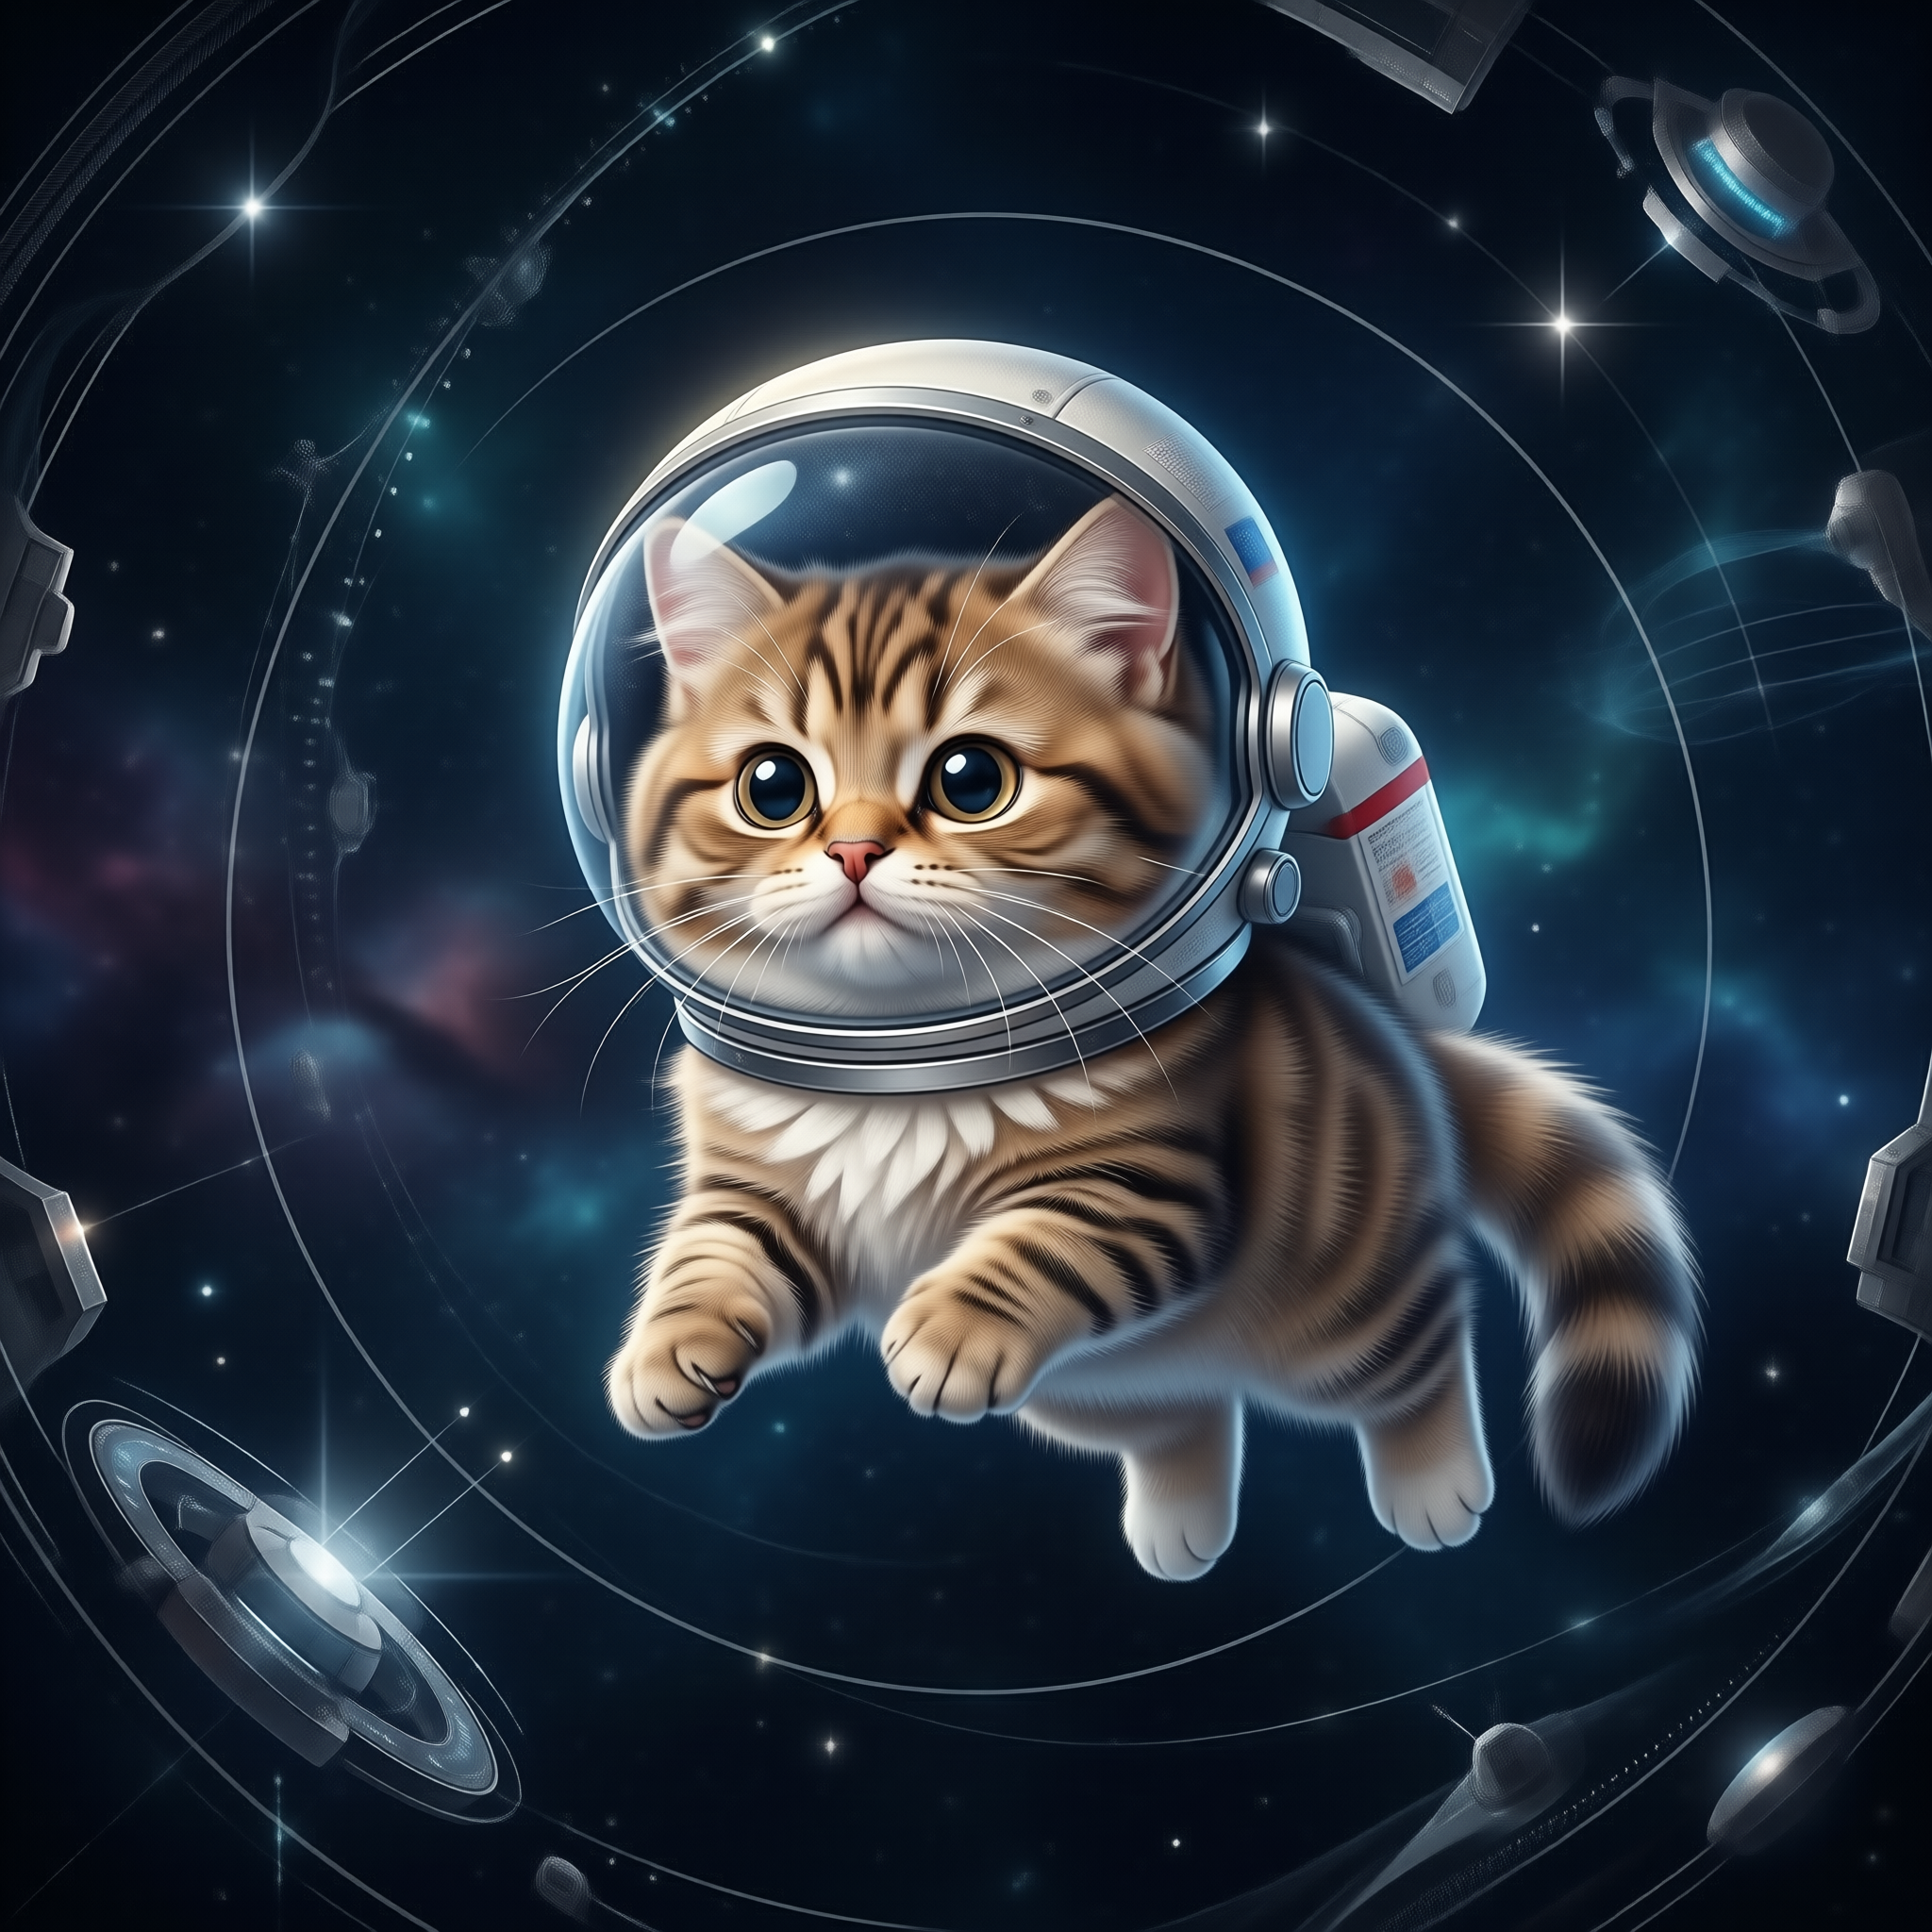

In [7]:
import requests
from IPython.display import Image, display

# Download and display the generated image
image_data = requests.get(image_url).content

# Save the image locally
with open("sensenova_generated_image.png", "wb") as f:
    f.write(image_data)

print("Image saved as sensenova_generated_image.png")
print("Displaying the generated image:")

# Display in notebook
display(Image(filename="sensenova_generated_image.png", width=512))

## 4. Conclusion

Congratulations! You have learned how to use the SenseNova API by SenseTime for both chat completions and image generation. Here is a summary of what we covered:

- **OpenAI SDK Compatibility**: The SenseNova API is fully compatible with the OpenAI Python SDK. Simply set base_url to https://token.sensenova.cn/v1 and use your SenseNova API key.
- **SenseNova 6.7 Flash-Lite**: A fast chat model with a unique **reasoning** field that provides transparency into the model chain-of-thought thinking process.
- **Multi-Turn Conversations**: The API supports full conversation history for context-aware responses.
- **SenseNova U1 Fast**: An image generation model that creates high-quality images from text prompts, returning signed URLs for easy access.

### Next Steps

- Explore other SenseNova models available on the platform.
- Try different image sizes and prompts for image generation.
- Build applications that combine chat and image generation capabilities.
- Visit the SenseNova Platform for more documentation and resources.